# Retail Sales EDA — Superstore Dataset

## Objective
Perform Exploratory Data Analysis on Superstore retail sales data to uncover sales trends, top-performing categories, regions, cities, states, and customer segments — and turn those into actionable business recommendations.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")   # <- this is what makes charts look "professional" instantly
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titleweight'] = 'bold'

print("Libraries imported and theme set!")

Libraries imported and theme set!


In [13]:
import os
os.makedirs("charts", exist_ok=True)
print("charts folder ready!")

charts folder ready!


In [9]:
df = pd.read_csv("train.csv")

print("Dataset Overview")
print("="*40)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Dataset Overview
Rows: 9800, Columns: 18

Missing values:
Postal Code    11
dtype: int64


## Data Cleaning

In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)
df['Postal Code'] = df['Postal Code'].fillna("Unknown")

duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)
print("Data cleaning complete. Shape:", df.shape)

Duplicate rows: 0
Data cleaning complete. Shape: (9800, 18)


In [11]:
print(df.describe())

            Row ID                  Order Date                   Ship Date  \
count  9800.000000                        9800                        9800   
mean   4900.500000  2017-05-01 05:13:51.673469  2017-05-05 04:17:52.653061   
min       1.000000         2015-01-03 00:00:00         2015-01-07 00:00:00   
25%    2450.750000         2016-05-24 00:00:00         2016-05-27 18:00:00   
50%    4900.500000         2017-06-26 00:00:00         2017-06-29 00:00:00   
75%    7350.250000         2018-05-15 00:00:00         2018-05-19 00:00:00   
max    9800.000000         2018-12-30 00:00:00         2019-01-05 00:00:00   
std    2829.160653                         NaN                         NaN   

              Sales  
count   9800.000000  
mean     230.769059  
min        0.444000  
25%       17.248000  
50%       54.490000  
75%      210.605000  
max    22638.480000  
std      626.651875  


In [23]:
print("Descriptive Statistics for Numeric Columns")
print("="*50)

print(df.describe())

Descriptive Statistics for Numeric Columns
            Row ID                  Order Date                   Ship Date  \
count  9800.000000                        9800                        9800   
mean   4900.500000  2017-05-01 05:13:51.673469  2017-05-05 04:17:52.653061   
min       1.000000         2015-01-03 00:00:00         2015-01-07 00:00:00   
25%    2450.750000         2016-05-24 00:00:00         2016-05-27 18:00:00   
50%    4900.500000         2017-06-26 00:00:00         2017-06-29 00:00:00   
75%    7350.250000         2018-05-15 00:00:00         2018-05-19 00:00:00   
max    9800.000000         2018-12-30 00:00:00         2019-01-05 00:00:00   
std    2829.160653                         NaN                         NaN   

              Sales         Year        Month  
count   9800.000000  9800.000000  9800.000000  
mean     230.769059  2016.724184     7.818469  
min        0.444000  2015.000000     1.000000  
25%       17.248000  2016.000000     5.000000  
50%       54.4

In [24]:
print("Monthly Sales Trend")
print("="*40)
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum()
print(monthly_sales)

Monthly Sales Trend
Year  Month
2015  1         14205.7070
      2          4519.8920
      3         55205.7970
      4         27906.8550
      5         23644.3030
      6         34322.9356
      7         33781.5430
      8         27117.5365
      9         81623.5268
      10        31453.3930
      11        77907.6607
      12        68167.0585
2016  1         18066.9576
      2         11951.4110
      3         32339.3184
      4         34154.4685
      5         29959.5305
      6         23599.3740
      7         28608.2590
      8         36818.3422
      9         63133.6060
      10        31011.7375
      11        75249.3995
      12        74543.6012
2017  1         18542.4910
      2         22978.8150
      3         51165.0590
      4         38679.7670
      5         56656.9080
      6         39724.4860
      7         38320.7830
      8         30542.2003
      9         69193.3909
      10        59583.0330
      11        79066.4958
      12        95739.1

In [25]:
print("Sales by Product Category")
print("="*40)
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

Sales by Product Category
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


## Chart 1: Monthly Sales Trend (with NumPy trendline)

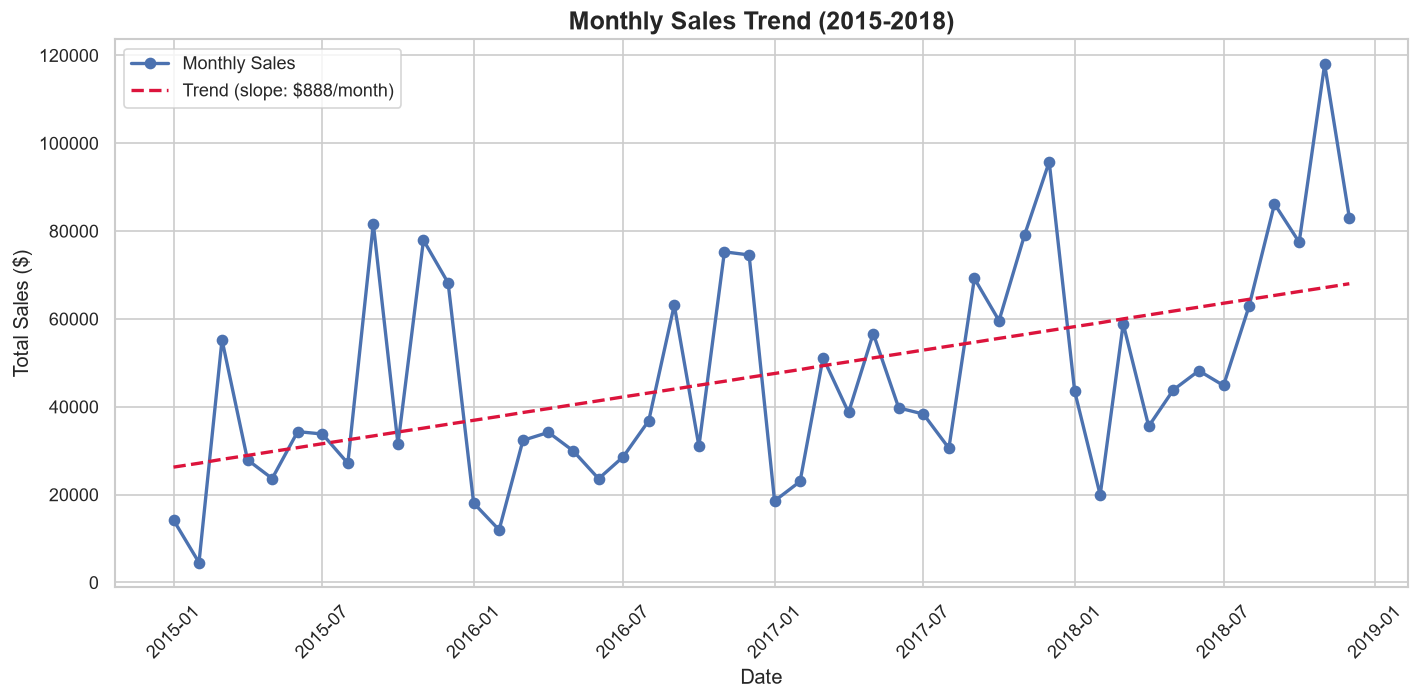

Trend slope: $888.31 per month -> GROWING


In [14]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
monthly_sales = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales['Year'].astype(str)+'-'+monthly_sales['Month'].astype(str)+'-01')

x = np.arange(len(monthly_sales))
z = np.polyfit(x, monthly_sales['Sales'], 1)
trend = np.poly1d(z)(x)

plt.figure(figsize=(12,6))
plt.plot(monthly_sales['Date'], monthly_sales['Sales'], marker='o', label='Monthly Sales', linewidth=2)
plt.plot(monthly_sales['Date'], trend, linestyle='--', color='crimson', linewidth=2, label=f'Trend (slope: ${z[0]:,.0f}/month)')
plt.title('Monthly Sales Trend (2015-2018)', fontsize=15)
plt.xlabel('Date'); plt.ylabel('Total Sales ($)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('charts/01_monthly_trend.png', dpi=300)
plt.show()
print(f"Trend slope: ${z[0]:,.2f} per month -> {'GROWING' if z[0]>0 else 'DECLINING'}")

## Chart 2: Sales by Product Category

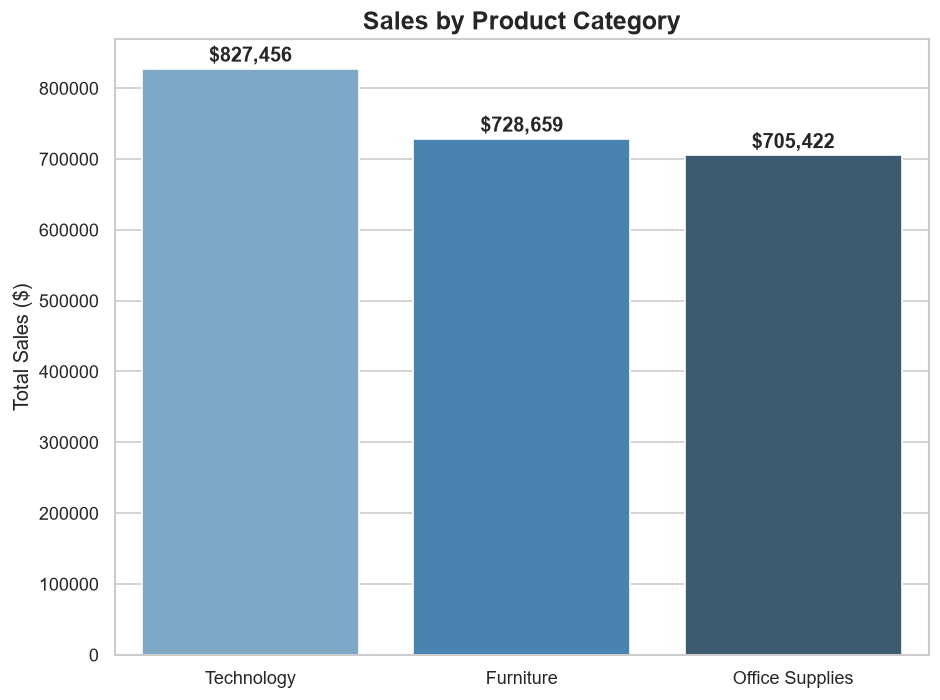

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


In [15]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,6))
ax = sns.barplot(x=category_sales.index, y=category_sales.values, hue=category_sales.index, palette="Blues_d", legend=False)
for i, v in enumerate(category_sales.values):
    ax.text(i, v + 10000, f"${v:,.0f}", ha='center', fontweight='bold')
plt.title('Sales by Product Category', fontsize=15)
plt.xlabel(''); plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('charts/02_category_sales.png', dpi=300)
plt.show()
print(category_sales)

## Chart 3: Sales by Region

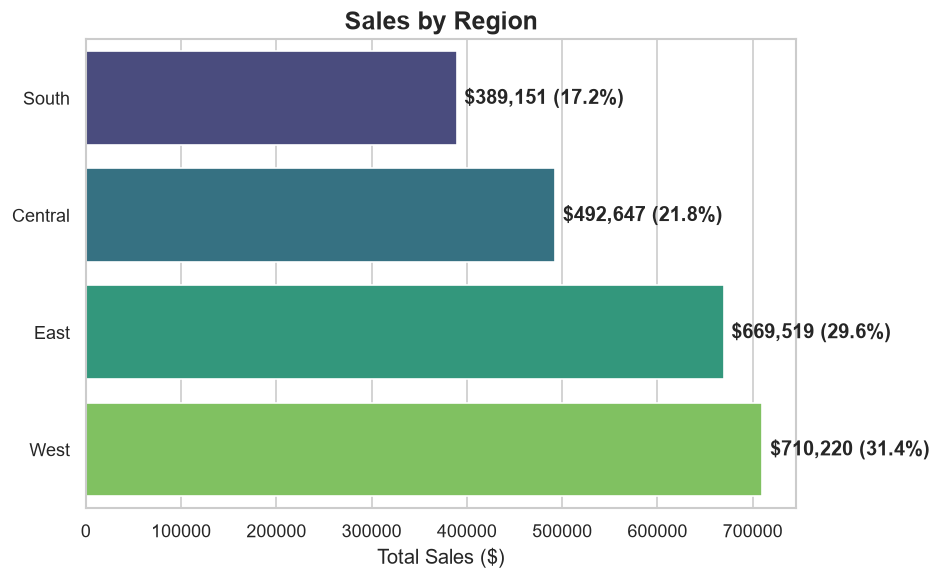

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


In [16]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=True)

plt.figure(figsize=(8,5))
ax = sns.barplot(x=region_sales.values, y=region_sales.index, hue=region_sales.index, palette="viridis", legend=False)
total = region_sales.sum()
for i, v in enumerate(region_sales.values):
    pct = v/total*100
    ax.text(v + 8000, i, f"${v:,.0f} ({pct:.1f}%)", va='center', fontweight='bold')
plt.title('Sales by Region', fontsize=15)
plt.xlabel('Total Sales ($)'); plt.ylabel('')
plt.tight_layout()
plt.savefig('charts/03_region_sales.png', dpi=300)
plt.show()
print(region_sales.sort_values(ascending=False))

## Chart 4: Top 10 Cities by Sales

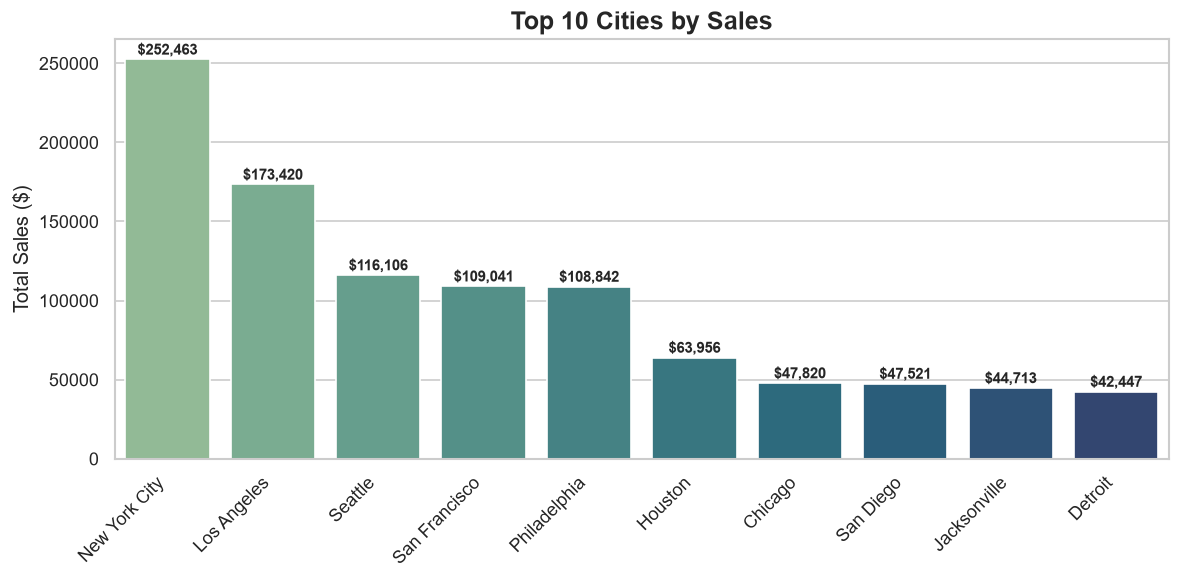

City
New York City    252462.5470
Los Angeles      173420.1810
Seattle          116106.3220
San Francisco    109041.1200
Philadelphia     108841.7490
Houston           63956.1428
Chicago           47820.1330
San Diego         47521.0290
Jacksonville      44713.1830
Detroit           42446.9440
Name: Sales, dtype: float64


In [17]:
city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
ax = sns.barplot(x=city_sales.index, y=city_sales.values, hue=city_sales.index, palette="crest", legend=False)
for i, v in enumerate(city_sales.values):
    ax.text(i, v + 3000, f"${v:,.0f}", ha='center', fontsize=9, fontweight='bold')
plt.title("Top 10 Cities by Sales", fontsize=15)
plt.xlabel(""); plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('charts/04_top_cities.png', dpi=300)
plt.show()
print(city_sales)

## Chart 5: Top 10 States by Sales

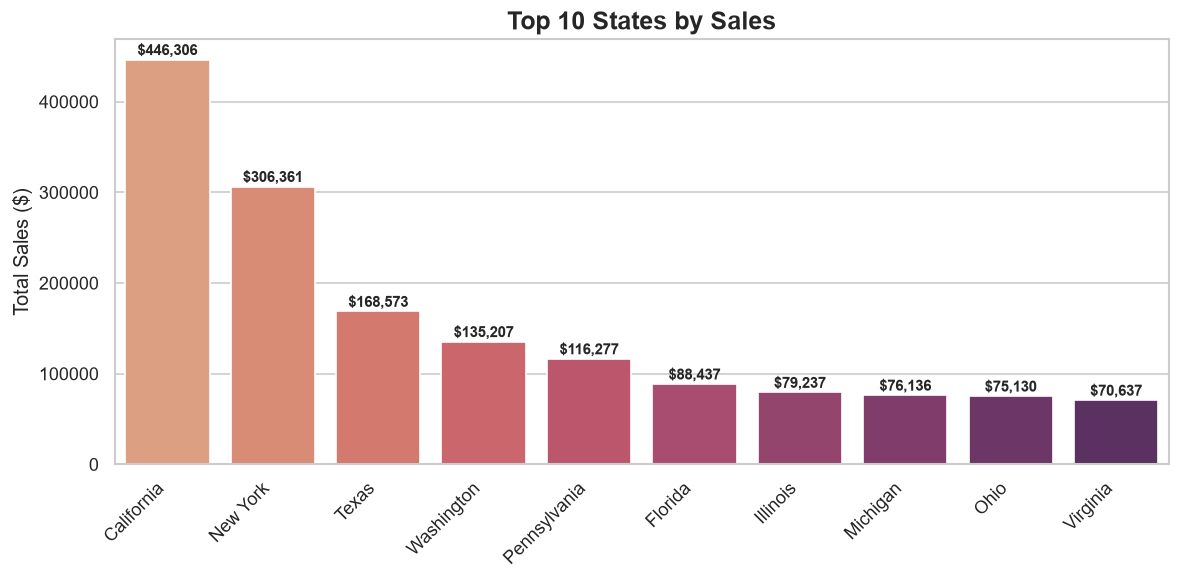

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64


In [18]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
ax = sns.barplot(x=state_sales.index, y=state_sales.values, hue=state_sales.index, palette="flare", legend=False)
for i, v in enumerate(state_sales.values):
    ax.text(i, v + 5000, f"${v:,.0f}", ha='center', fontsize=9, fontweight='bold')
plt.title("Top 10 States by Sales", fontsize=15)
plt.xlabel(""); plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('charts/05_top_states.png', dpi=300)
plt.show()
print(state_sales)

## Chart 6: Sales by Customer Segment

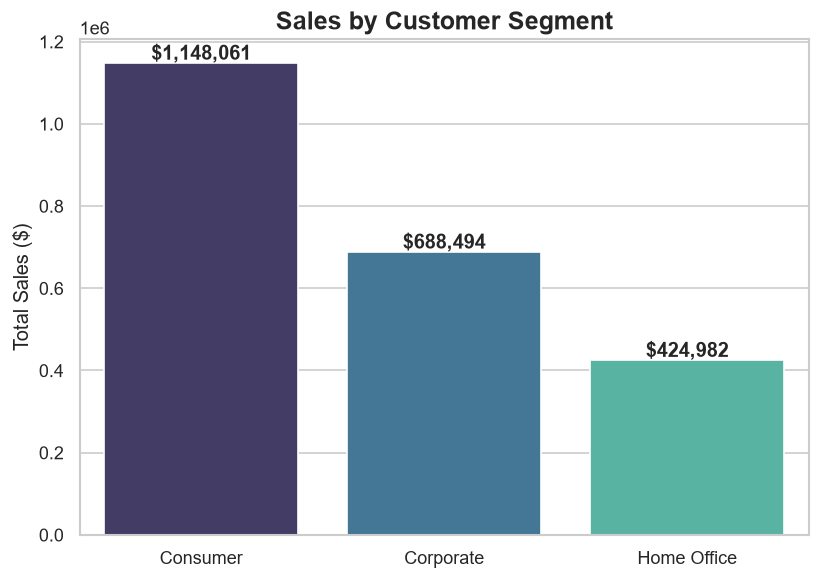

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


In [19]:
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(7,5))
ax = sns.barplot(x=segment_sales.index, y=segment_sales.values, hue=segment_sales.index, palette="mako", legend=False)
for i, v in enumerate(segment_sales.values):
    ax.text(i, v + 8000, f"${v:,.0f}", ha='center', fontweight='bold')
plt.title("Sales by Customer Segment", fontsize=15)
plt.xlabel(""); plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.savefig('charts/06_segment_sales.png', dpi=300)
plt.show()
print(segment_sales)

## Chart 7: Top 10 Revenue Products

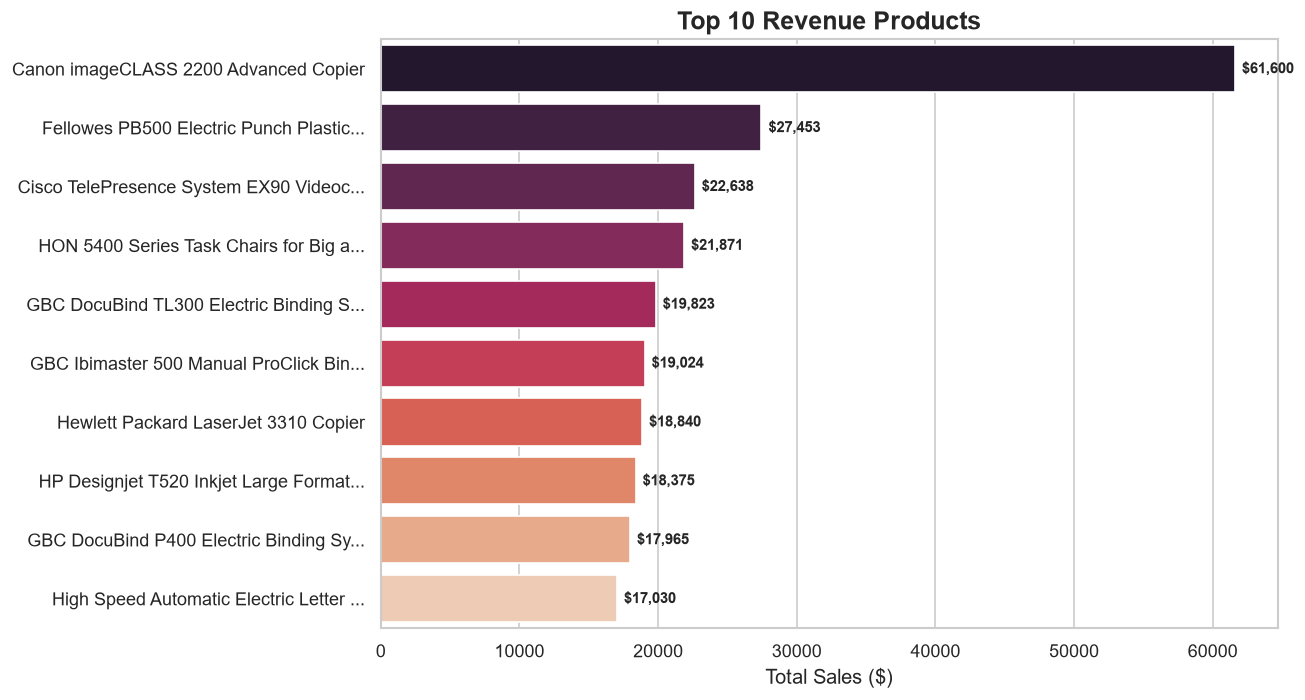

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [20]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
# shorten long product names so labels stay readable
short_labels = [name if len(name) <= 40 else name[:37] + "..." for name in top_products.index]

plt.figure(figsize=(11,6))
ax = sns.barplot(x=top_products.values, y=short_labels, hue=short_labels, palette="rocket", legend=False)
for i, v in enumerate(top_products.values):
    ax.text(v + 500, i, f"${v:,.0f}", va='center', fontsize=9, fontweight='bold')
plt.title("Top 10 Revenue Products", fontsize=15)
plt.xlabel("Total Sales ($)"); plt.ylabel("")
plt.tight_layout()
plt.savefig('charts/07_top_products.png', dpi=300)
plt.show()
print(top_products)

## Chart 8: Sales by Region and Category

Category    Furniture  Office Supplies  Technology
Region                                            
Central   160317.4622       163590.243  168739.208
East      206461.3880       199940.811  263116.527
South     116531.4800       124424.771  148195.208
West      245348.2455       217466.509  247404.930


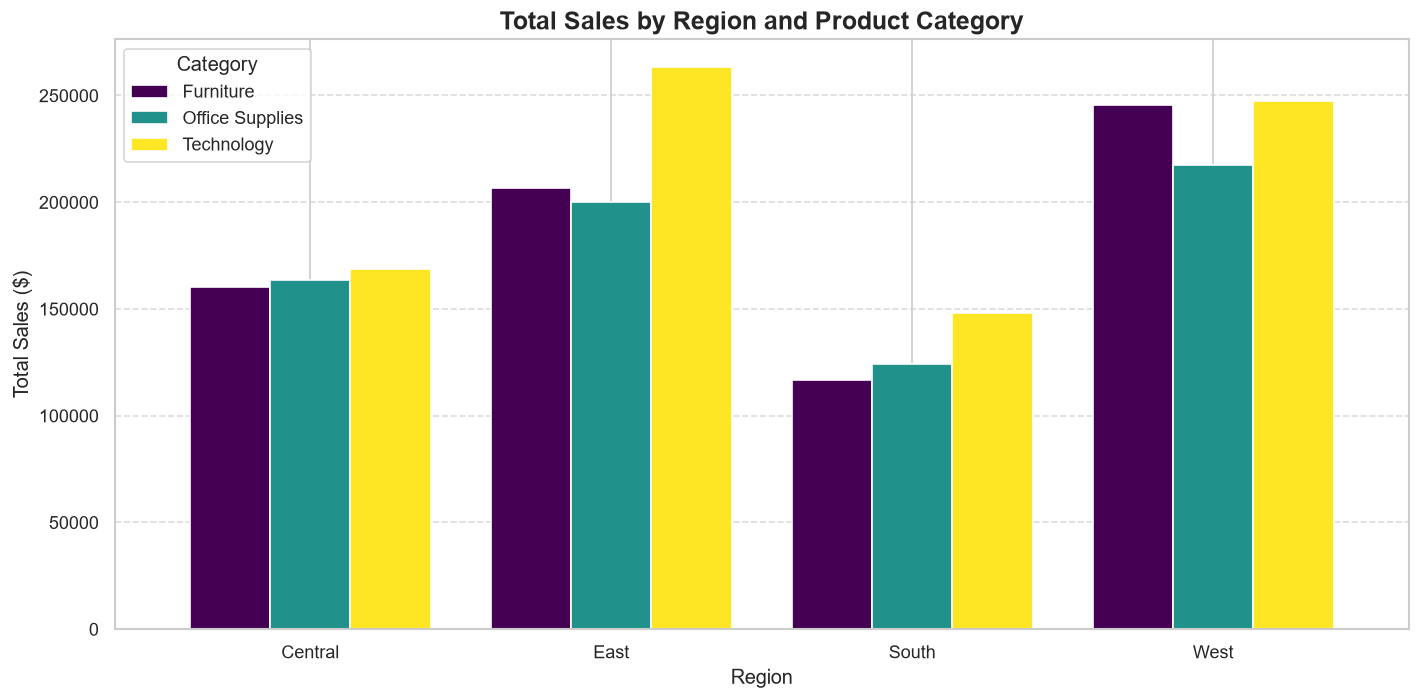

In [21]:
region_category = df.groupby(['Region', 'Category'])['Sales'].sum().unstack()
print(region_category)

region_category.plot(kind='bar', figsize=(12,6), width=0.8, colormap='viridis')
plt.title('Total Sales by Region and Product Category', fontsize=15)
plt.xlabel('Region'); plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Category')
plt.tight_layout()
plt.savefig('charts/08_region_category.png', dpi=300)
plt.show()

## Chart 9: Customer Segment vs Ship Mode

Ship Mode    First Class  Same Day  Second Class  Standard Class
Segment                                                         
Consumer             755       312          1003            3031
Corporate            468       114           589            1782
Home Office          278       112           310            1046


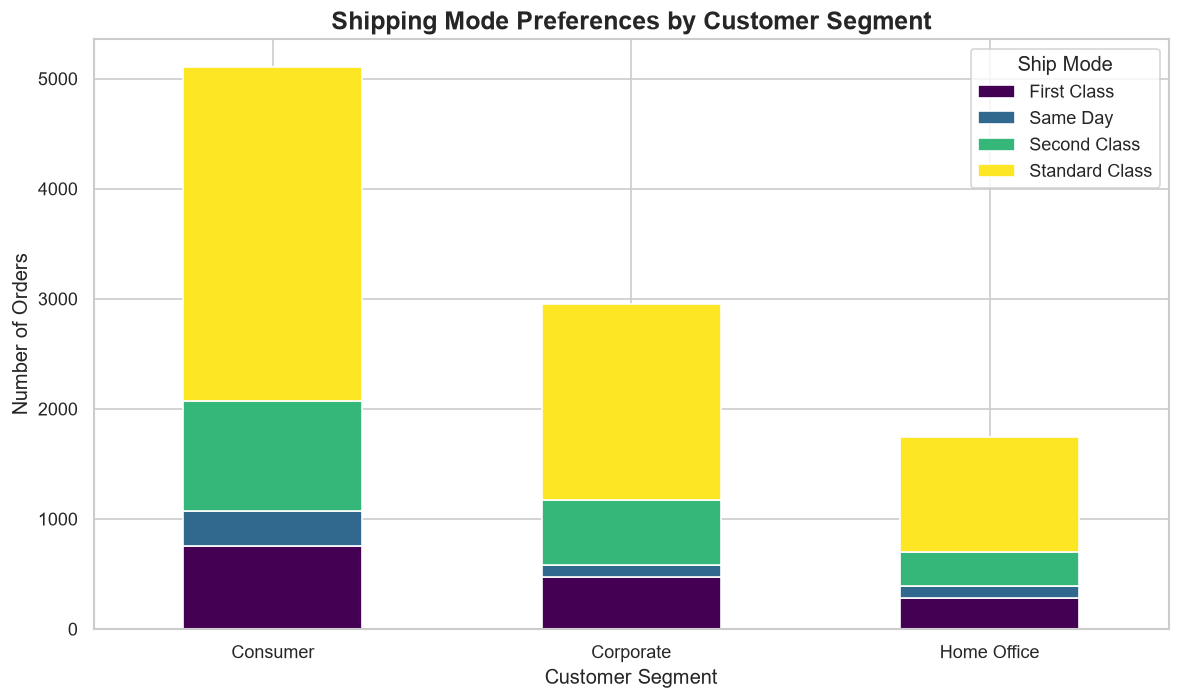

In [22]:
segment_ship = pd.crosstab(df['Segment'], df['Ship Mode'])
print(segment_ship)

segment_ship.plot(kind='bar', stacked=True, figsize=(10,6), colormap='viridis')
plt.title('Shipping Mode Preferences by Customer Segment', fontsize=15)
plt.xlabel('Customer Segment'); plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.legend(title='Ship Mode')
plt.tight_layout()
plt.savefig('charts/09_segment_shipmode.png', dpi=300)
plt.show()

## chart 10: Histogram

Pie Chart - Sales by Region


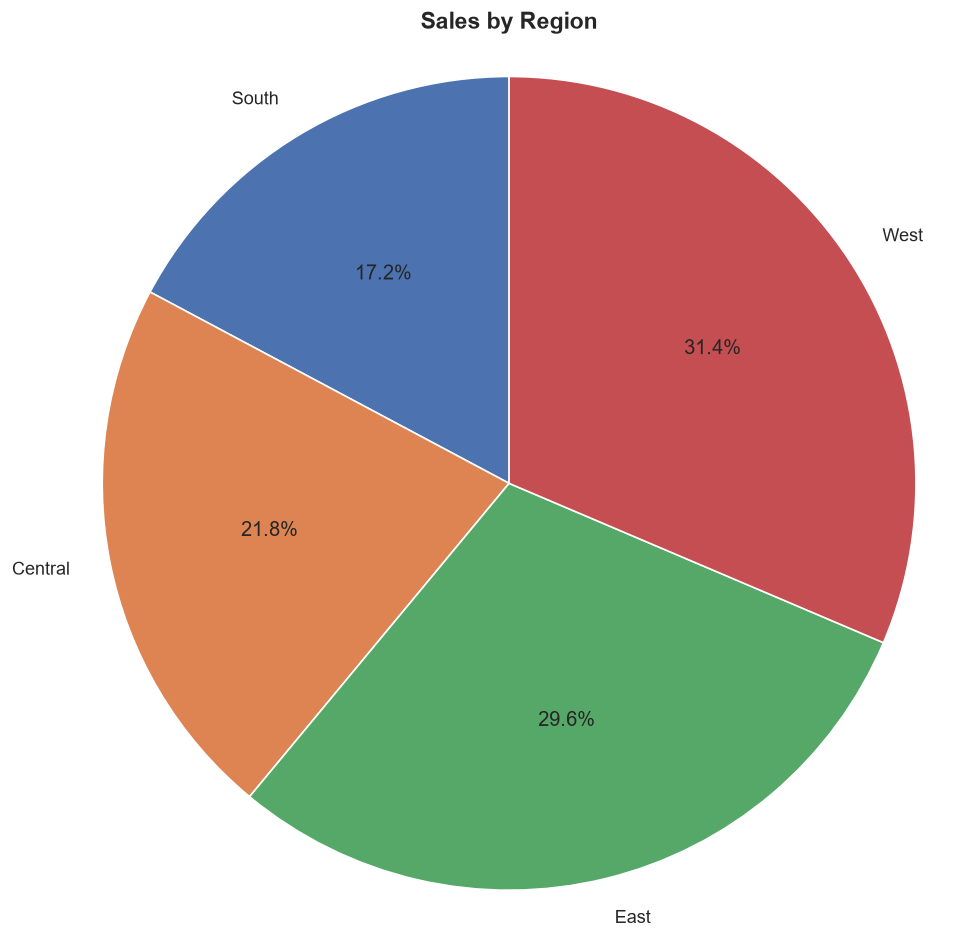

In [26]:
print("Pie Chart - Sales by Region")
print("="*40)

plt.figure(figsize=(8, 8))
plt.pie(region_sales.values, labels=region_sales.index, autopct='%1.1f%%', startangle=90)
plt.title('Sales by Region', fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.show()

## chart 11

## Conclusion and Business Recommendations

### Key Findings
1. Sales are trending upward over time, growing by roughly $888 per month on average (2015-2018), with strong seasonal peaks in September and November.
2. Technology is the highest-selling category ($827K), followed by Furniture ($729K) and Office Supplies ($705K).
3. The West region contributes the most sales (31.4%), while the South region lags at 17.2%.
4. New York City, Los Angeles, and Seattle are the top 3 cities; California, New York, and Texas are the top 3 states — sales are heavily concentrated in a small number of major markets.
5. Consumer segment drives the most revenue ($1.15M), nearly double the Corporate segment.

### Business Recommendations
1. **Protect and grow the West region's lead** while investigating why the South underperforms (pricing, distribution, or demand issues).
2. **Prepare inventory and staffing ahead of September and November peaks** to avoid stockouts during high-demand periods.
3. **Double down on top markets** (NYC, LA, Seattle, California, New York, Texas) with targeted local marketing, while testing growth strategies in underrepresented cities/states.
4. **Bundle Technology products with Furniture/Office Supplies** to lift basket size, since Technology is the clear category leader.
5. **Tailor marketing toward the Consumer segment** given its outsized share of revenue, while exploring why Corporate and Home Office lag behind.